1. Имеются (сгенерированы) 3 выборки объёмом n = 100. Для каждой из
них:
- если имеется необходимость, сгруппировать данные, вычислив
оптимальное число интервалов
- вычислить начальные и центральные моменты (до 4 порядка,
включительно), моду, медиану, исправленную дисперсию, коэффициенты
асимметрии и эксцесса – сделать предварительные выводы
- построить полигон, «ящик с усами», записать эмпирическую функцию
распределения и построить её график

  ЗАДАНИЕ 1 — АНАЛИЗ ТРЁХ ВЫБОРОК (n = 100)

─────────────────────────────────────────────────────────────────
  Выборка 1 (Нормальное)
─────────────────────────────────────────────────────────────────
  Оптимальное число интервалов (Стёрджес): 8

  Начальные моменты:
    ν1 = 4.7923
    ν2 = 26.2323
    ν3 = 155.9829
    ν4 = 988.0177
  Центральные моменты:
    μ1 = 0.0000
    μ2 = 3.2661
    μ3 = -1.0345
    μ4 = 30.3443

  Среднее (x̄):               4.7923
  Медиана:                    4.7461
  Мода:                       -0.2395
  Исправленная дисперсия S²:  3.2991
  Среднеквадр. отклонение S:  1.8163
  Коэффициент асимметрии:     -0.1753
  Коэффициент эксцесса:       -0.1554

  Предварительные выводы:
    • Распределение симметрично (асимметрия ≈ 0)
    • Эксцесс ≈ 0 → форма близка к нормальному

─────────────────────────────────────────────────────────────────
  Выборка 2 (Экспоненциальное)
─────────────────────────────────────────────────────────────────
  Оптимальное число инт

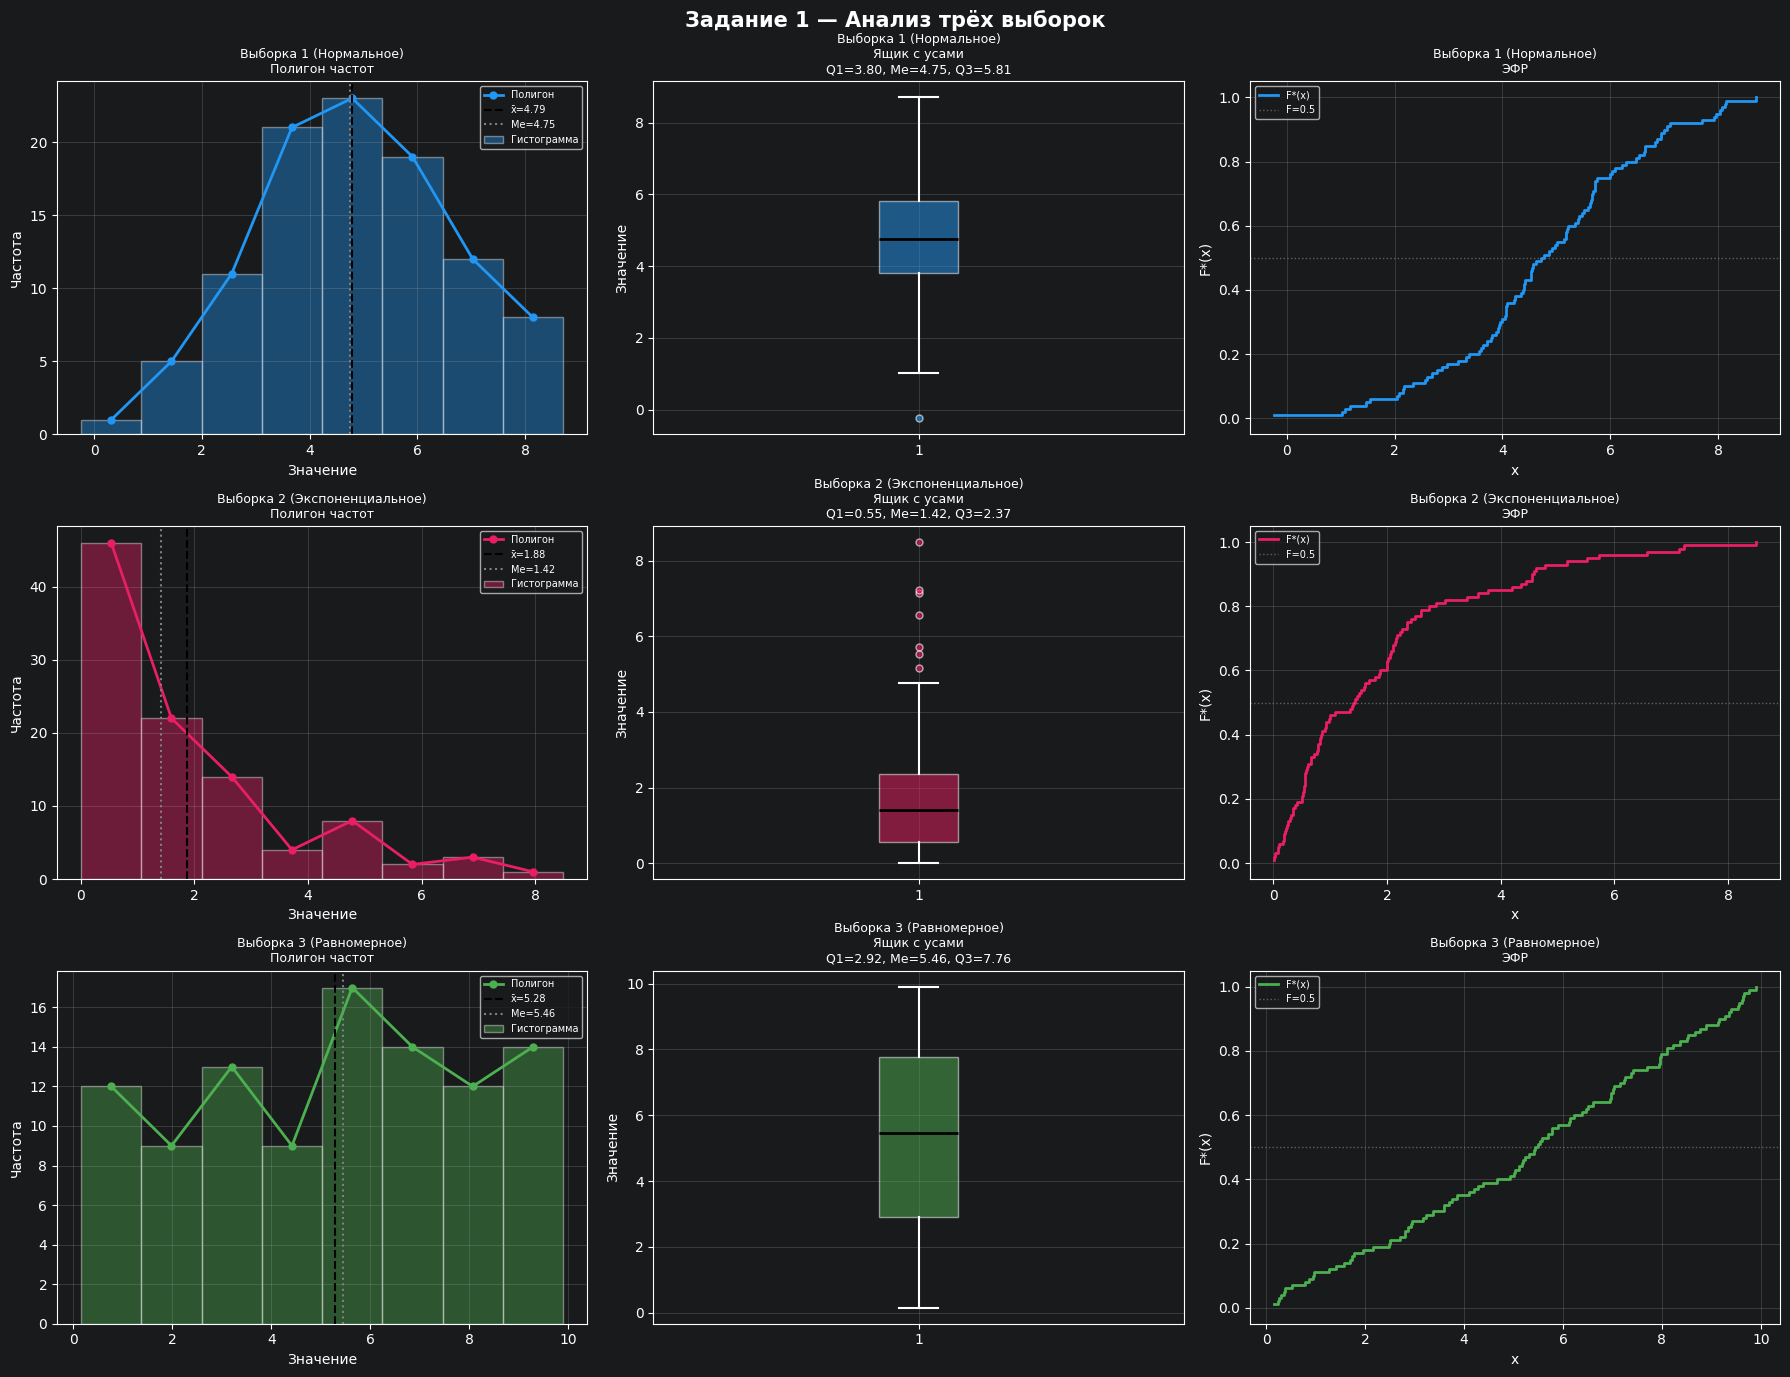


✓ Графики сохранены: task1_graphs.png
✓ Скрипт: task1_stat.py


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ============================================================
# ГЕНЕРАЦИЯ ВЫБОРОК
# ============================================================
np.random.seed(42)
n = 100

sample1 = np.random.normal(loc=5, scale=2, size=n)       # Нормальное
sample2 = np.random.exponential(scale=2, size=n)          # Экспоненциальное
sample3 = np.random.uniform(low=0, high=10, size=n)       # Равномерное

samples = {
    "Выборка 1 (Нормальное)": sample1,
    "Выборка 2 (Экспоненциальное)": sample2,
    "Выборка 3 (Равномерное)": sample3,
}

# ============================================================
# ФУНКЦИИ АНАЛИЗА
# ============================================================

def optimal_intervals(data):
    """Формула Стёрджеса для числа интервалов"""
    return int(np.ceil(1 + np.log2(len(data))))

def raw_moments(data, max_order=4):
    """Начальные моменты"""
    return [np.mean(data**k) for k in range(1, max_order + 1)]

def central_moments(data, max_order=4):
    """Центральные моменты"""
    mean = np.mean(data)
    return [np.mean((data - mean)**k) for k in range(1, max_order + 1)]

def compute_stats(data):
    mean = np.mean(data)
    median = np.median(data)
    mode_result = stats.mode(data, keepdims=True)
    mode_val = mode_result.mode[0]

    mu2 = np.mean((data - mean)**2)          # Центральный момент 2-го порядка
    s2 = np.var(data, ddof=1)                # Исправленная дисперсия
    s = np.std(data, ddof=1)

    mu3 = np.mean((data - mean)**3)
    mu4 = np.mean((data - mean)**4)

    skewness = mu3 / (mu2 ** 1.5)           # Коэффициент асимметрии
    kurtosis = mu4 / (mu2 ** 2) - 3         # Коэффициент эксцесса

    return {
        "mean": mean,
        "median": median,
        "mode": mode_val,
        "s2": s2,
        "s": s,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "mu1": np.mean(data - mean),
        "mu2": mu2,
        "mu3": mu3,
        "mu4": mu4,
    }

def empirical_cdf(data):
    """Эмпирическая функция распределения"""
    x_sorted = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x_sorted, y

# ============================================================
# ВЫВОД ЧИСЛОВЫХ ХАРАКТЕРИСТИК
# ============================================================
print("=" * 65)
print("  ЗАДАНИЕ 1 — АНАЛИЗ ТРЁХ ВЫБОРОК (n = 100)")
print("=" * 65)

for name, data in samples.items():
    k = optimal_intervals(data)
    st = compute_stats(data)
    rm = raw_moments(data)
    cm = central_moments(data)

    print(f"\n{'─'*65}")
    print(f"  {name}")
    print(f"{'─'*65}")
    print(f"  Оптимальное число интервалов (Стёрджес): {k}")
    print()
    print(f"  Начальные моменты:")
    for i, m in enumerate(rm, 1):
        print(f"    ν{i} = {m:.4f}")
    print(f"  Центральные моменты:")
    for i, m in enumerate(cm, 1):
        print(f"    μ{i} = {m:.4f}")
    print()
    print(f"  Среднее (x̄):               {st['mean']:.4f}")
    print(f"  Медиана:                    {st['median']:.4f}")
    print(f"  Мода:                       {st['mode']:.4f}")
    print(f"  Исправленная дисперсия S²:  {st['s2']:.4f}")
    print(f"  Среднеквадр. отклонение S:  {st['s']:.4f}")
    print(f"  Коэффициент асимметрии:     {st['skewness']:.4f}")
    print(f"  Коэффициент эксцесса:       {st['kurtosis']:.4f}")

    # Предварительные выводы
    print()
    print("  Предварительные выводы:")
    sk = st['skewness']
    ku = st['kurtosis']
    if abs(sk) < 0.2:
        print(f"    • Распределение симметрично (асимметрия ≈ 0)")
    elif sk > 0:
        print(f"    • Правосторонняя асимметрия (длинный правый хвост)")
    else:
        print(f"    • Левосторонняя асимметрия (длинный левый хвост)")

    if abs(ku) < 0.5:
        print(f"    • Эксцесс ≈ 0 → форма близка к нормальному")
    elif ku > 0:
        print(f"    • Положительный эксцесс → острый пик (лептокуртическое)")
    else:
        print(f"    • Отрицательный эксцесс → плоский пик (платикуртическое)")

# ============================================================
# ГРАФИКИ
# ============================================================
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Задание 1 — Анализ трёх выборок", fontsize=15, fontweight='bold', y=0.98)

colors = ['#2196F3', '#E91E63', '#4CAF50']

for idx, (name, data) in enumerate(samples.items()):
    k = optimal_intervals(data)
    st = compute_stats(data)
    x_cdf, y_cdf = empirical_cdf(data)
    color = colors[idx]

    # --- Полигон (гистограмма + полигон частот) ---
    ax1 = fig.add_subplot(3, 3, idx * 3 + 1)
    counts, bin_edges = np.histogram(data, bins=k)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax1.bar(bin_edges[:-1], counts, width=np.diff(bin_edges),
            color=color, alpha=0.4, edgecolor='white', align='edge', label='Гистограмма')
    ax1.plot(bin_centers, counts, 'o-', color=color, linewidth=2,
             markersize=5, label='Полигон')
    ax1.axvline(st['mean'], color='black', linestyle='--', linewidth=1.5, label=f"x̄={st['mean']:.2f}")
    ax1.axvline(st['median'], color='gray', linestyle=':', linewidth=1.5, label=f"Me={st['median']:.2f}")
    ax1.set_title(f"{name}\nПолигон частот", fontsize=9)
    ax1.legend(fontsize=7)
    ax1.set_xlabel("Значение")
    ax1.set_ylabel("Частота")
    ax1.grid(alpha=0.3)

    # --- Ящик с усами ---
    ax2 = fig.add_subplot(3, 3, idx * 3 + 2)
    bp = ax2.boxplot(data, vert=True, patch_artist=True,
                     boxprops=dict(facecolor=color, alpha=0.5),
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor=color, markersize=5, alpha=0.6))
    q1, q3 = np.percentile(data, [25, 75])
    ax2.set_title(f"{name}\nЯщик с усами\nQ1={q1:.2f}, Me={st['median']:.2f}, Q3={q3:.2f}", fontsize=9)
    ax2.set_ylabel("Значение")
    ax2.grid(alpha=0.3)

    # --- Эмпирическая функция распределения ---
    ax3 = fig.add_subplot(3, 3, idx * 3 + 3)
    # Ступенчатый график (настоящая ЭФР)
    ax3.step(x_cdf, y_cdf, where='post', color=color, linewidth=2, label='F*(x)')
    ax3.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='F=0.5')
    ax3.set_title(f"{name}\nЭФР", fontsize=9)
    ax3.set_xlabel("x")
    ax3.set_ylabel("F*(x)")
    ax3.legend(fontsize=7)
    ax3.grid(alpha=0.3)
    ax3.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("task1_graphs.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Графики сохранены: task1_graphs.png")
print("✓ Скрипт: task1_stat.py")

2. Сделать предположение о распределении генеральной совокупности, из
которой извлечена выборка:
- простроить точечные оценки параметров распределений
- построить численные оценки доверительных интервалов параметров
- найти теоретические частоты и построить многоугольник распределения
на том-же графике, что и многоугольник распределения, построенный по
выборочным данным.

  ЗАДАНИЕ 2 — ОЦЕНКА ПАРАМЕТРОВ И ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ

─────────────────────────────────────────────────────────────────
  Выборка 1  →  Предполагаемое распределение: Нормальное N(μ, σ²)
─────────────────────────────────────────────────────────────────

  Точечные оценки параметров (МНК/ММП):
    μ (среднее) = 4.7923
    σ (ст. откл.) = 1.8163

  Доверительные интервалы (уровень доверия 95%):
    μ: (4.4319,  5.1527)
    σ²: (2.5432,  4.4521)

  Теоретические частоты (k=8 интервалов):
    Интервал    Эмпир.     Теор.
           1         1      1.28
           2         5      4.63
           3        11     11.59
           4        21     20.12
           5        23     24.17
           6        19     20.13
           7        12     11.61
           8         8      4.64

─────────────────────────────────────────────────────────────────
  Выборка 2  →  Предполагаемое распределение: Экспоненциальное Exp(λ)
─────────────────────────────────────────────────────────────────

  Точ

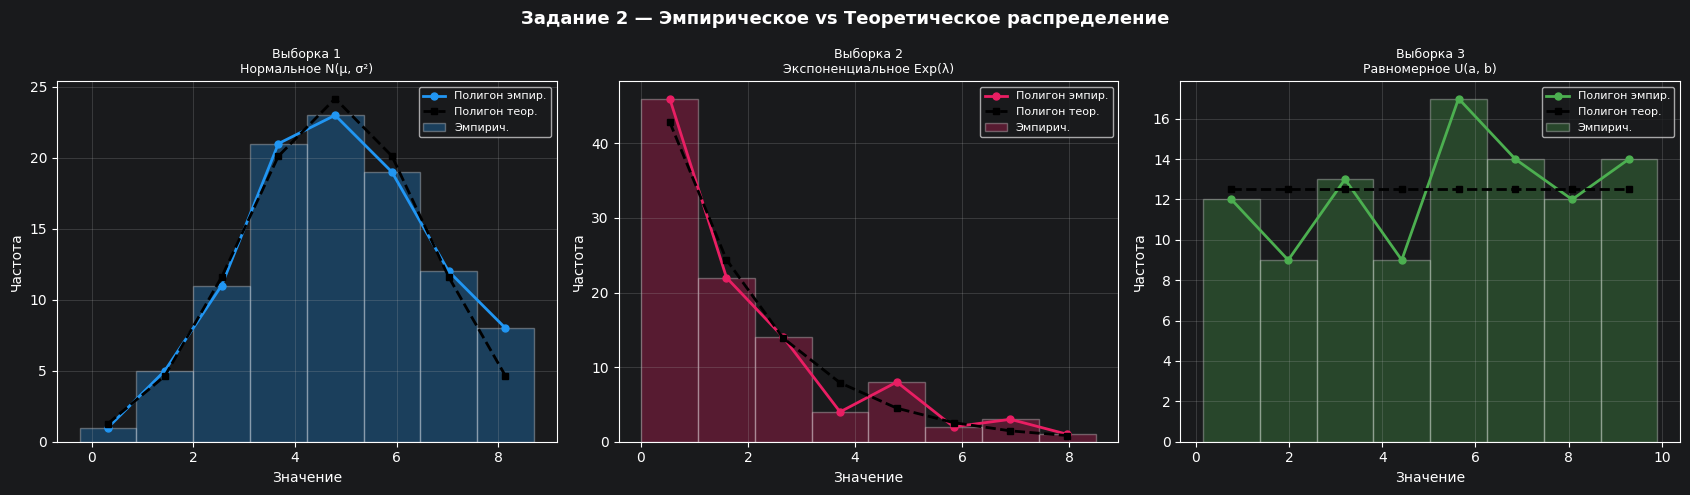


✓ Графики сохранены: task2_graphs.png


In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# ВЫБОРКИ (те же что в задании 1)
# ============================================================
np.random.seed(42)
n = 100

sample1 = np.random.normal(loc=5, scale=2, size=n)
sample2 = np.random.exponential(scale=2, size=n)
sample3 = np.random.uniform(low=0, high=10, size=n)

samples = {
    "Выборка 1": sample1,
    "Выборка 2": sample2,
    "Выборка 3": sample3,
}

# ============================================================
# ТОЧЕЧНЫЕ ОЦЕНКИ ПАРАМЕТРОВ
# ============================================================
def point_estimates(data, dist_name):
    """МНК / ММП точечные оценки параметров"""
    if dist_name == "normal":
        mu = np.mean(data)
        sigma = np.std(data, ddof=1)
        return {"μ (среднее)": mu, "σ (ст. откл.)": sigma}
    elif dist_name == "expon":
        lam = 1 / np.mean(data)
        return {"λ (интенсивность)": lam, "scale (=1/λ)": 1/lam}
    elif dist_name == "uniform":
        a = np.min(data)
        b = np.max(data)
        return {"a (мин)": a, "b (макс)": b}

# ============================================================
# ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ
# ============================================================
def confidence_intervals(data, dist_name, alpha=0.05):
    """Численные доверительные интервалы (уровень доверия 95%)"""
    n = len(data)
    intervals = {}

    if dist_name == "normal":
        mu = np.mean(data)
        s = np.std(data, ddof=1)
        # Для μ: t-распределение
        t = stats.t.ppf(1 - alpha/2, df=n-1)
        delta_mu = t * s / np.sqrt(n)
        intervals["μ"] = (mu - delta_mu, mu + delta_mu)
        # Для σ²: хи-квадрат
        chi2_low = stats.chi2.ppf(alpha/2, df=n-1)
        chi2_high = stats.chi2.ppf(1 - alpha/2, df=n-1)
        s2 = s**2
        intervals["σ²"] = ((n-1)*s2 / chi2_high, (n-1)*s2 / chi2_low)

    elif dist_name == "expon":
        lam_hat = 1 / np.mean(data)
        # Для λ через хи-квадрат (точный интервал)
        chi2_low = stats.chi2.ppf(alpha/2, df=2*n)
        chi2_high = stats.chi2.ppf(1 - alpha/2, df=2*n)
        sum_x = np.sum(data)
        intervals["λ"] = (chi2_low / (2*sum_x), chi2_high / (2*sum_x))

    elif dist_name == "uniform":
        a_hat = np.min(data)
        b_hat = np.max(data)
        # Приближённый интервал через порядковые статистики
        delta = (b_hat - a_hat) * (alpha/2) ** (1/n)
        intervals["a"] = (a_hat - delta, a_hat + delta)
        intervals["b"] = (b_hat - delta, b_hat + delta)

    return intervals

# ============================================================
# ТЕОРЕТИЧЕСКИЕ ЧАСТОТЫ
# ============================================================
def theoretical_frequencies(data, dist_name, k):
    """Теоретические частоты для каждого интервала"""
    counts, bin_edges = np.histogram(data, bins=k)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    n = len(data)

    if dist_name == "normal":
        mu, sigma = np.mean(data), np.std(data, ddof=1)
        probs = np.diff(stats.norm.cdf(bin_edges, loc=mu, scale=sigma))
    elif dist_name == "expon":
        scale = np.mean(data)
        probs = np.diff(stats.expon.cdf(bin_edges, scale=scale))
    elif dist_name == "uniform":
        a, b = np.min(data), np.max(data)
        probs = np.diff(stats.uniform.cdf(bin_edges, loc=a, scale=b-a))

    theoretical = probs * n
    return bin_edges, bin_centers, counts, theoretical

# ============================================================
# ВЫВОД РЕЗУЛЬТАТОВ
# ============================================================
dist_names = ["normal", "expon", "uniform"]
dist_labels = ["Нормальное N(μ, σ²)", "Экспоненциальное Exp(λ)", "Равномерное U(a, b)"]

print("=" * 65)
print("  ЗАДАНИЕ 2 — ОЦЕНКА ПАРАМЕТРОВ И ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ")
print("=" * 65)

for (name, data), dist_name, dist_label in zip(samples.items(), dist_names, dist_labels):
    k = int(np.ceil(1 + np.log2(len(data))))
    print(f"\n{'─'*65}")
    print(f"  {name}  →  Предполагаемое распределение: {dist_label}")
    print(f"{'─'*65}")

    # Точечные оценки
    print("\n  Точечные оценки параметров (МНК/ММП):")
    pe = point_estimates(data, dist_name)
    for param, val in pe.items():
        print(f"    {param} = {val:.4f}")

    # Доверительные интервалы
    print("\n  Доверительные интервалы (уровень доверия 95%):")
    ci = confidence_intervals(data, dist_name)
    for param, (lo, hi) in ci.items():
        print(f"    {param}: ({lo:.4f},  {hi:.4f})")

    # Теоретические частоты
    _, _, emp_counts, theo_counts = theoretical_frequencies(data, dist_name, k)
    print(f"\n  Теоретические частоты (k={k} интервалов):")
    print(f"    {'Интервал':>8}  {'Эмпир.':>8}  {'Теор.':>8}")
    for i, (e, t) in enumerate(zip(emp_counts, theo_counts)):
        print(f"    {i+1:>8}  {e:>8}  {t:>8.2f}")

# ============================================================
# ГРАФИКИ: полигоны эмпирический + теоретический
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Задание 2 — Эмпирическое vs Теоретическое распределение",
             fontsize=13, fontweight='bold')

colors = ['#2196F3', '#E91E63', '#4CAF50']

for idx, ((name, data), dist_name, dist_label) in enumerate(
        zip(samples.items(), dist_names, dist_labels)):

    k = int(np.ceil(1 + np.log2(len(data))))
    bin_edges, bin_centers, emp_counts, theo_counts = theoretical_frequencies(data, dist_name, k)
    color = colors[idx]
    ax = axes[idx]

    # Гистограмма
    ax.bar(bin_edges[:-1], emp_counts, width=np.diff(bin_edges),
           color=color, alpha=0.3, edgecolor='white', align='edge', label='Эмпирич.')

    # Полигон эмпирический
    ax.plot(bin_centers, emp_counts, 'o-', color=color,
            linewidth=2, markersize=5, label='Полигон эмпир.')

    # Полигон теоретический
    ax.plot(bin_centers, theo_counts, 's--', color='black',
            linewidth=2, markersize=5, label='Полигон теор.')

    ax.set_title(f"{name}\n{dist_label}", fontsize=9)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Частота")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task2_graphs.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Графики сохранены: task2_graphs.png")

3. Дополнительное задание: сгенерировать небольшую выборку с
распределением Пуассона (Бернулли) и проверить гипотезу о значении
параметра распределения (для распределений Пуассона и Бернулли)

  ЗАДАНИЕ 3 — ПРОВЕРКА ГИПОТЕЗ

─────────────────────────────────────────────────────────────────
  РАСПРЕДЕЛЕНИЕ ПУАССОНА
─────────────────────────────────────────────────────────────────

  Выборка: n = 50, истинное λ = 3
  Проверяем: H0: λ = 3.0  vs  H1: λ ≠ 3.0

  Точечная оценка λ̂ = x̄ = 2.7800

  Тестовая статистика Z = -0.8981
  Критическое значение  z_крит = ±1.9600  (α = 0.05)
  p-value = 0.3691

  Вывод: |Z| = 0.8981 < 1.9600 = z_крит
  → H0 НЕ ОТВЕРГАЕТСЯ. Нет оснований считать λ ≠ 3.0

─────────────────────────────────────────────────────────────────
  РАСПРЕДЕЛЕНИЕ БЕРНУЛЛИ
─────────────────────────────────────────────────────────────────

  Выборка: n = 50, истинное p = 0.4
  Проверяем: H0: p = 0.4  vs  H1: p ≠ 0.4

  Точечная оценка p̂ = 0.4800
  Число успехов: 24 из 50

  Тестовая статистика Z = 1.1547
  Критическое значение  z_крит = ±1.9600  (α = 0.05)
  p-value = 0.2482

  Вывод: |Z| = 1.1547 < 1.9600 = z_крит
  → H0 НЕ ОТВЕРГАЕТСЯ. Нет оснований считать p ≠ 0.4


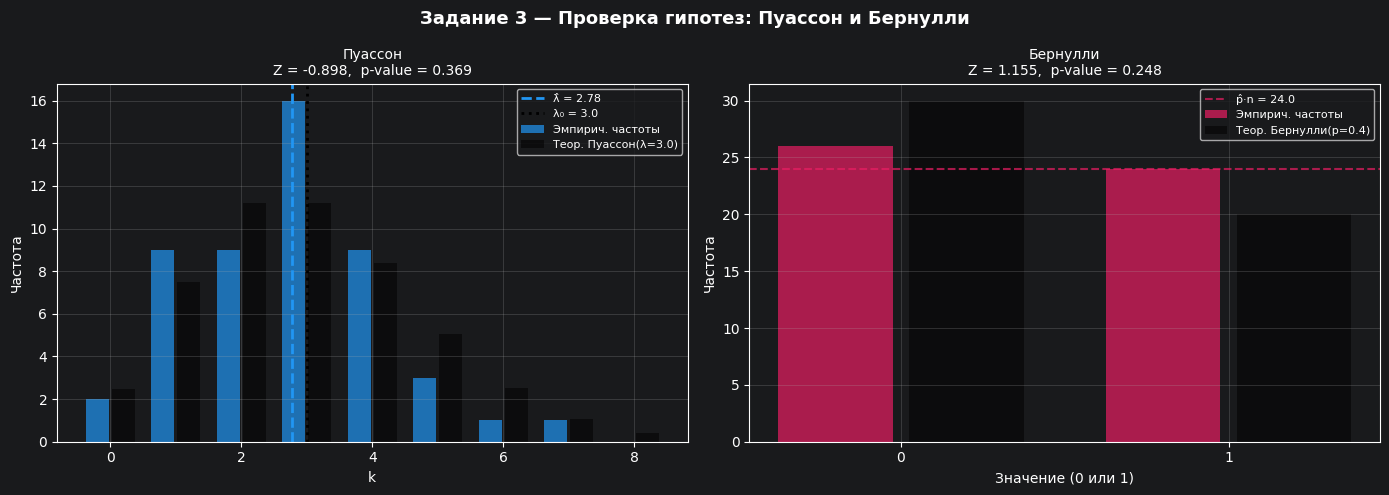


✓ Графики сохранены: task3_graphs.png


In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# ГЕНЕРАЦИЯ ВЫБОРОК
# ============================================================
np.random.seed(42)

# Пуассон: истинный параметр λ = 3
lambda_true = 3
n_poisson = 50
sample_poisson = np.random.poisson(lam=lambda_true, size=n_poisson)

# Бернулли: истинный параметр p = 0.4
p_true = 0.4
n_bern = 50
sample_bern = np.random.binomial(n=1, p=p_true, size=n_bern)

# ============================================================
# ПРОВЕРКА ГИПОТЕЗЫ ДЛЯ ПУАССОНА
# ============================================================
# H0: λ = λ0   vs   H1: λ ≠ λ0
# Статистика: через хи-квадрат (точный критерий через сумму)
# При H0: 2λ0*n ~ χ²(2n), используем нормальное приближение
# Z = (x̄ - λ0) / sqrt(λ0/n)  ~  N(0,1)

print("=" * 65)
print("  ЗАДАНИЕ 3 — ПРОВЕРКА ГИПОТЕЗ")
print("=" * 65)

print("\n" + "─"*65)
print("  РАСПРЕДЕЛЕНИЕ ПУАССОНА")
print("─"*65)

lambda_hat = np.mean(sample_poisson)
lambda0 = 3.0   # гипотетическое значение

print(f"\n  Выборка: n = {n_poisson}, истинное λ = {lambda_true}")
print(f"  Проверяем: H0: λ = {lambda0}  vs  H1: λ ≠ {lambda0}")
print(f"\n  Точечная оценка λ̂ = x̄ = {lambda_hat:.4f}")

# Тестовая статистика (нормальное приближение)
Z_poisson = (lambda_hat - lambda0) / np.sqrt(lambda0 / n_poisson)
p_value_poisson = 2 * (1 - stats.norm.cdf(abs(Z_poisson)))
z_crit = stats.norm.ppf(0.975)  # критическое значение α=0.05

print(f"\n  Тестовая статистика Z = {Z_poisson:.4f}")
print(f"  Критическое значение  z_крит = ±{z_crit:.4f}  (α = 0.05)")
print(f"  p-value = {p_value_poisson:.4f}")
print()
if abs(Z_poisson) < z_crit:
    print(f"  Вывод: |Z| = {abs(Z_poisson):.4f} < {z_crit:.4f} = z_крит")
    print(f"  → H0 НЕ ОТВЕРГАЕТСЯ. Нет оснований считать λ ≠ {lambda0}")
else:
    print(f"  Вывод: |Z| = {abs(Z_poisson):.4f} > {z_crit:.4f} = z_крит")
    print(f"  → H0 ОТВЕРГАЕТСЯ. Данные противоречат λ = {lambda0}")

# ============================================================
# ПРОВЕРКА ГИПОТЕЗЫ ДЛЯ БЕРНУЛЛИ
# ============================================================
# H0: p = p0   vs   H1: p ≠ p0
# Статистика: Z = (p̂ - p0) / sqrt(p0*(1-p0)/n)  ~  N(0,1)

print("\n" + "─"*65)
print("  РАСПРЕДЕЛЕНИЕ БЕРНУЛЛИ")
print("─"*65)

p_hat = np.mean(sample_bern)
p0 = 0.4   # гипотетическое значение

print(f"\n  Выборка: n = {n_bern}, истинное p = {p_true}")
print(f"  Проверяем: H0: p = {p0}  vs  H1: p ≠ {p0}")
print(f"\n  Точечная оценка p̂ = {p_hat:.4f}")
print(f"  Число успехов: {int(np.sum(sample_bern))} из {n_bern}")

Z_bern = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n_bern)
p_value_bern = 2 * (1 - stats.norm.cdf(abs(Z_bern)))

print(f"\n  Тестовая статистика Z = {Z_bern:.4f}")
print(f"  Критическое значение  z_крит = ±{z_crit:.4f}  (α = 0.05)")
print(f"  p-value = {p_value_bern:.4f}")
print()
if abs(Z_bern) < z_crit:
    print(f"  Вывод: |Z| = {abs(Z_bern):.4f} < {z_crit:.4f} = z_крит")
    print(f"  → H0 НЕ ОТВЕРГАЕТСЯ. Нет оснований считать p ≠ {p0}")
else:
    print(f"  Вывод: |Z| = {abs(Z_bern):.4f} > {z_crit:.4f} = z_крит")
    print(f"  → H0 ОТВЕРГАЕТСЯ. Данные противоречат p = {p0}")

# ============================================================
# ГРАФИКИ
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Задание 3 — Проверка гипотез: Пуассон и Бернулли",
             fontsize=13, fontweight='bold')

# --- График 1: Пуассон ---
ax1 = axes[0]
values, counts = np.unique(sample_poisson, return_counts=True)
x_range = np.arange(0, max(values) + 2)
theo_probs = stats.poisson.pmf(x_range, mu=lambda0) * n_poisson

ax1.bar(values - 0.2, counts, width=0.35, color='#2196F3',
        alpha=0.7, label='Эмпирич. частоты')
ax1.bar(x_range + 0.2, theo_probs, width=0.35, color='black',
        alpha=0.5, label=f'Теор. Пуассон(λ={lambda0})')
ax1.axvline(lambda_hat, color='#2196F3', linestyle='--',
            linewidth=2, label=f'λ̂ = {lambda_hat:.2f}')
ax1.axvline(lambda0, color='black', linestyle=':',
            linewidth=2, label=f'λ₀ = {lambda0}')
ax1.set_title(f"Пуассон\nZ = {Z_poisson:.3f},  p-value = {p_value_poisson:.3f}", fontsize=10)
ax1.set_xlabel("k")
ax1.set_ylabel("Частота")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# --- График 2: Бернулли ---
ax2 = axes[1]
n_ones = int(np.sum(sample_bern))
n_zeros = n_bern - n_ones
theo_0 = (1 - p0) * n_bern
theo_1 = p0 * n_bern

x = np.array([0, 1])
ax2.bar(x - 0.2, [n_zeros, n_ones], width=0.35, color='#E91E63',
        alpha=0.7, label='Эмпирич. частоты')
ax2.bar(x + 0.2, [theo_0, theo_1], width=0.35, color='black',
        alpha=0.5, label=f'Теор. Бернулли(p={p0})')
ax2.axhline(p_hat * n_bern, color='#E91E63', linestyle='--',
            linewidth=1.5, alpha=0.7, label=f'p̂·n = {p_hat*n_bern:.1f}')
ax2.set_title(f"Бернулли\nZ = {Z_bern:.3f},  p-value = {p_value_bern:.3f}", fontsize=10)
ax2.set_xlabel("Значение (0 или 1)")
ax2.set_ylabel("Частота")
ax2.set_xticks([0, 1])
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task3_graphs.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Графики сохранены: task3_graphs.png")